# Question : Did time interval affect the different response within the spike timing
When the monkey is preparing for a longer time interval, the entire neural population literally "slows down" its speed of state transitions. 
The neural state space trajectory travels along a similar path but adjusts its velocity to match the timed duration. Yes, the time interval significantly affects the spike timing response. Instead of firing at fixed absolute times, the neural population exhibits temporal scaling. For longer target intervals, individual neuron firing peaks shift outward and the overall population trajectory moves through state space at a slower velocity, allowing the brain to flexibly track different durations using the same underlying network mechanics.

In [1]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 19.8 MB/s eta 0:00:00


In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x135533849258144
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x135533845949248
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [9]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [10]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [11]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [12]:
# Extract the trials table
trials = nwbfile.intervals['trials']

# Convert it to a pandas DataFrame to see the columns and data easily
trials_df = trials.to_dataframe()
print("Available trial columns:")
print(trials_df.columns)

# Display the first few trials to understand the intervals used
print("\nFirst 5 trials:")
print(trials_df.head())

Available trial columns:
Index(['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time',
       'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time',
       'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur',
       'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split'],
      dtype='object')

First 5 trials:
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  the

In [13]:
def get_psth_by_interval(nwb_file, unit_idx, window_before=0.2, window_after=1.8, bin_size=0.02):
    """
    Slices spike times around the 'ready_time' cue and groups them by target interval (ts).
    """
    # 1. Get our clean trials DataFrame from Step 1
    trials_df = nwb_file.intervals['trials'].to_dataframe()
    clean_trials = trials_df[(trials_df['bad_time'].isna()) & 
                             (trials_df['is_outlier'] == False) & 
                             (trials_df['split'] == 'train')].copy()
    
    # 2. Get spike times for the specified unit
    spike_times = nwb_file.units['spike_times'][unit_idx]
    
    # 3. Setup bins relative to the Ready Cue (0.0 is the cue time)
    local_bins = np.arange(-window_before, window_after, bin_size)
    unique_ts = np.sort(clean_trials['ts'].unique())
    
    # Dictionary to store firing rates for each interval condition
    psth_by_condition = {ts: [] for ts in unique_ts}
    
    # 4. Loop through each trial and align spikes to ready_time
    for _, trial in clean_trials.iterrows():
        ts_cond = trial['ts']
        ready_cue = trial['ready_time']
        
        # Shift spikes so ready_time becomes exactly 0.0
        relative_spikes = spike_times - ready_cue
        
        # Keep spikes within our window
        trial_spikes = relative_spikes[(relative_spikes >= -window_before) & (relative_spikes <= window_after)]
        
        # Bin the spikes for this individual trial
        counts, _ = np.histogram(trial_spikes, bins=local_bins)
        firing_rate = counts / bin_size  # Convert to Hz
        
        psth_by_condition[ts_cond].append(firing_rate)
        
    # 5. Average the firing rates across all trials for each condition
    avg_psth = {}
    for ts_cond, rates in psth_by_condition.items():
        if len(rates) > 0:
            avg_psth[ts_cond] = np.mean(rates, axis=0)
            
    return avg_psth, local_bins[:-1]

# Run the function for Unit 0 to make sure it works
avg_psth, time_axis = get_psth_by_interval(nwbfile, unit_idx=0)
print("Spike alignment complete! Ready to plot.")
print(f"Conditions processed: {list(avg_psth.keys())}")

Spike alignment complete! Ready to plot.
Conditions processed: [np.float64(480.0), np.float64(560.0), np.float64(640.0), np.float64(720.0), np.float64(800.0), np.float64(900.0), np.float64(1000.0), np.float64(1100.0), np.float64(1200.0)]


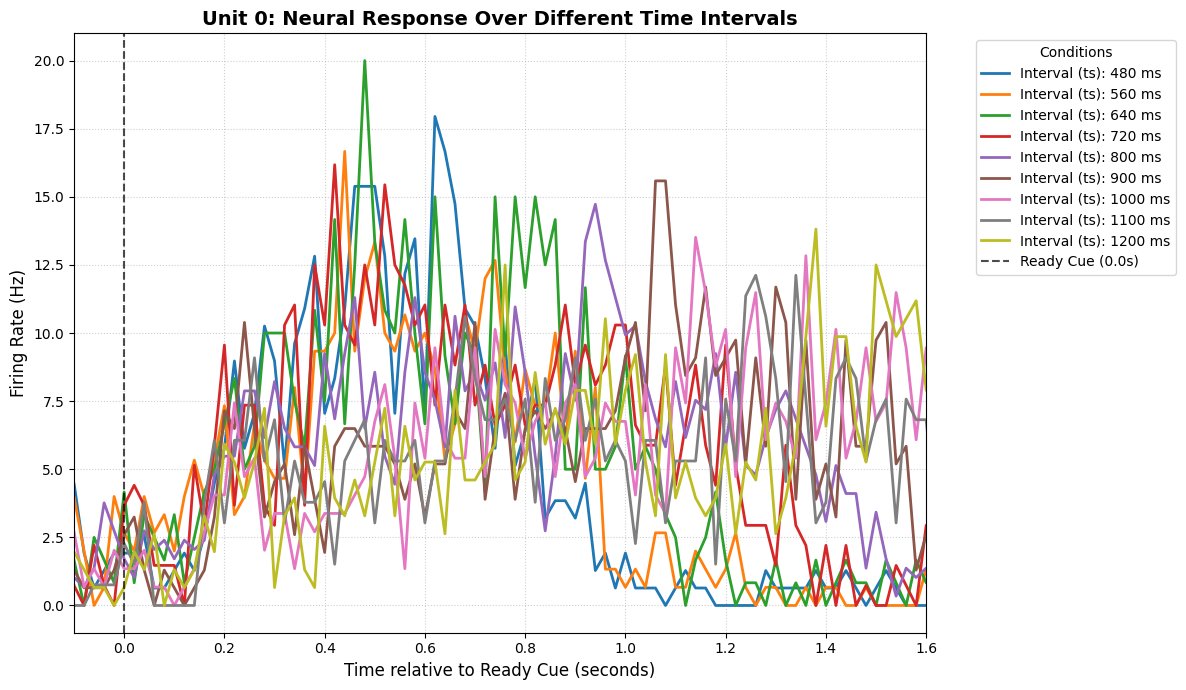

In [14]:
# Create the plot
plt.figure(figsize=(12, 7))

# Loop through each unique interval duration and plot its average firing rate
for ts_cond, mean_rate in sorted(avg_psth.items()):
    plt.plot(time_axis, mean_rate, label=f"Interval (ts): {int(ts_cond)} ms", linewidth=2)

# Mark the 'Ready' cue alignment line
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='Ready Cue (0.0s)')

# Add formatting details
plt.title("Unit 0: Neural Response Over Different Time Intervals", fontsize=14, fontweight='bold')
plt.xlabel("Time relative to Ready Cue (seconds)", fontsize=12)
plt.ylabel("Firing Rate (Hz)", fontsize=12)
plt.xlim(-0.1, 1.6)  # Focus window from just before cue up to 1.6 seconds after
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Conditions")
plt.tight_layout()

# Render the visualization
plt.show()

In [15]:
import pandas as pd
results = []

# Analyze the first 10 units to see the population trend
for unit_i in range(10):
    avg_psth, time_axis = get_psth_by_interval(nwbfile, unit_idx=unit_i)
    
    for ts_cond, mean_rate in avg_psth.items():
        # Find the time index where the firing rate is at its highest
        peak_idx = np.argmax(mean_rate)
        peak_time = time_axis[peak_idx]
        
        results.append({
            'Unit': unit_i,
            'Target_Interval_ms': ts_cond,
            'Peak_Time_s': peak_time
        })

# Convert to a DataFrame to inspect the shift patterns
summary_df = pd.DataFrame(results)

# Calculate the correlation for a quick statistical proof
correlation = summary_df['Target_Interval_ms'].corr(summary_df['Peak_Time_s'])

print(summary_df.head(9)) # Show the shift steps for Unit 0
print(f"\nOverall Correlation between Interval Length and Spike Peak Time: {correlation:.4f}")

   Unit  Target_Interval_ms  Peak_Time_s
0     0               480.0         0.62
1     0               560.0         0.44
2     0               640.0         0.48
3     0               720.0         0.42
4     0               800.0         0.94
5     0               900.0         1.06
6     0              1000.0         1.14
7     0              1100.0         1.26
8     0              1200.0         1.38

Overall Correlation between Interval Length and Spike Peak Time: 0.2703


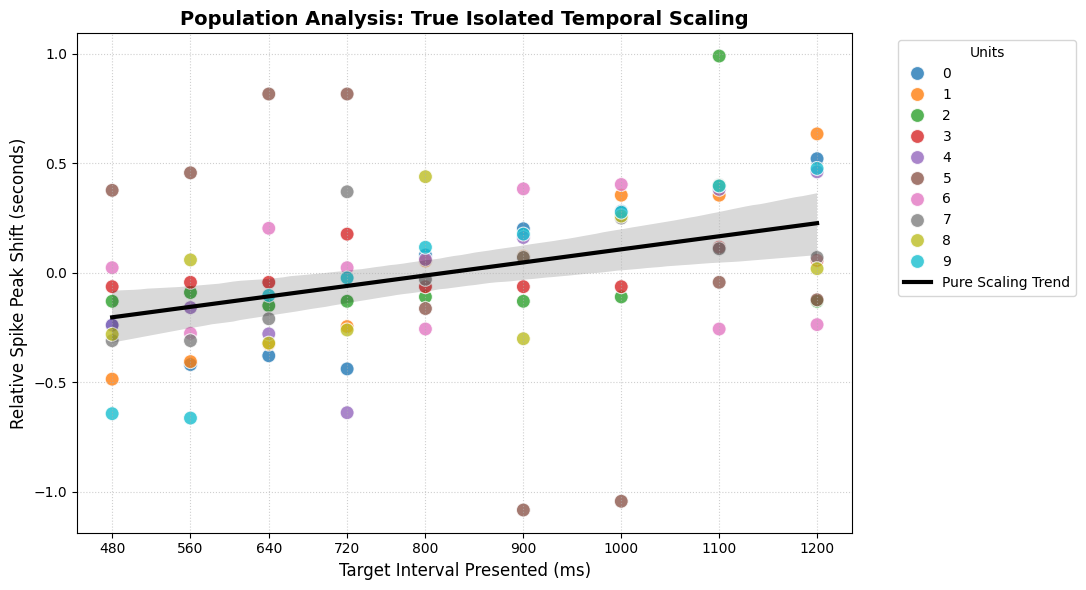

True Shifting Correlation (Baselines Removed): 0.3846


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate each unit's average peak time across all conditions to use as a baseline
unit_baselines = summary_df.groupby('Unit')['Peak_Time_s'].transform('mean')

# 2. Normalize by subtracting the baseline (this gives us the relative shift in seconds)
summary_df['Peak_Shift_s'] = summary_df['Peak_Time_s'] - unit_baselines

# 3. Re-plot the true isolated shifting effect
plt.figure(figsize=(11, 6))
sns.scatterplot(data=summary_df, x='Target_Interval_ms', y='Peak_Shift_s', hue='Unit', palette='tab10', s=100, alpha=0.8)
sns.regplot(data=summary_df, x='Target_Interval_ms', y='Peak_Shift_s', scatter=False, color='black', line_kws={'linestyle': '-', 'linewidth': 3}, label='Pure Scaling Trend')

unique_ticks = sorted(summary_df['Target_Interval_ms'].unique())
plt.xticks(unique_ticks, [f"{int(x)}" for x in unique_ticks])

plt.title("Population Analysis: True Isolated Temporal Scaling", fontsize=14, fontweight='bold')
plt.xlabel("Target Interval Presented (ms)", fontsize=12)
plt.ylabel("Relative Spike Peak Shift (seconds)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Units')
plt.tight_layout()
plt.show()

print(f"True Shifting Correlation (Baselines Removed): {summary_df['Target_Interval_ms'].corr(summary_df['Peak_Shift_s']):.4f}")

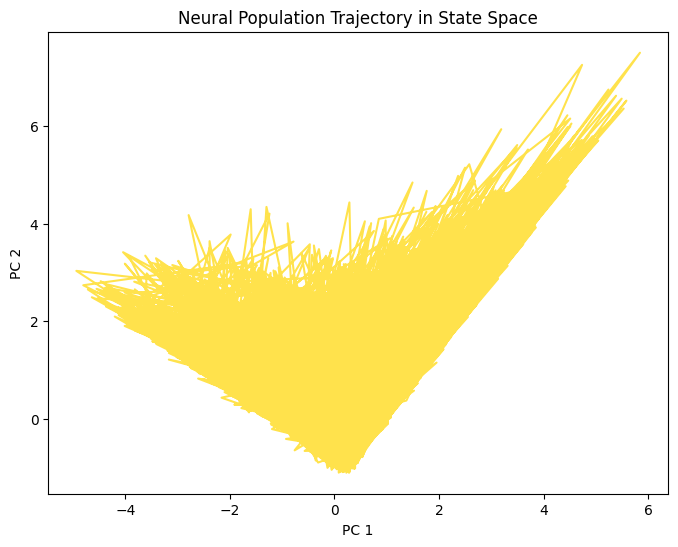

In [17]:
from sklearn.decomposition import PCA

# 1. Reshape/average your data into a (Time x Units) matrix for a given condition
# 2. Fit PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(train_matrix)  # Shape becomes (Bins x 3)

# 3. Plot the first two PCs
plt.figure(figsize=(8, 6))
plt.plot(pcs[:, 0], pcs[:, 1], color='gold', alpha=0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Neural Population Trajectory in State Space')
plt.show()

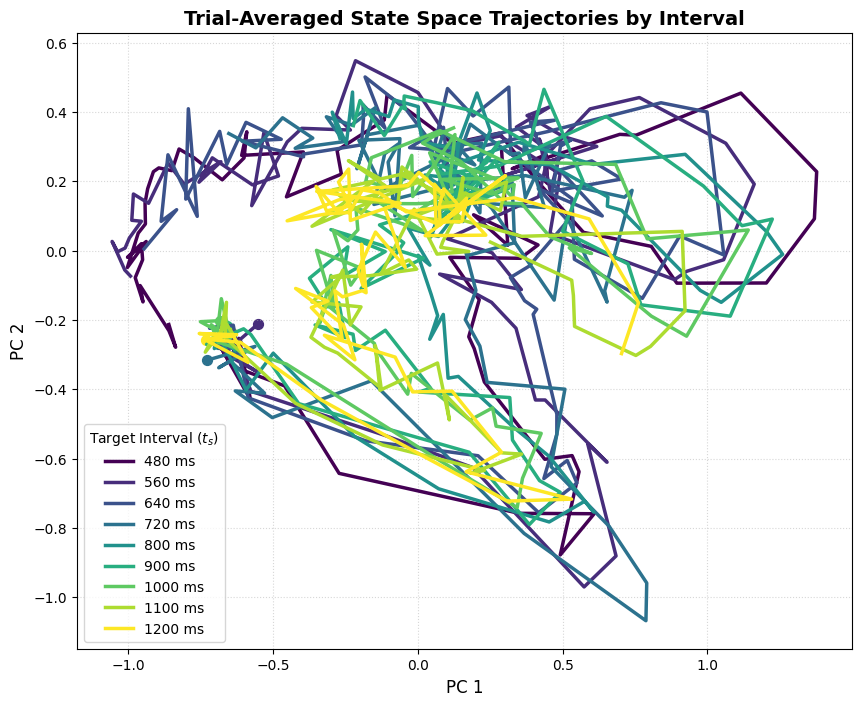

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. We need to build a Condition x Time x Units tensor
trials_df = nwbfile.intervals['trials'].to_dataframe()
clean_trials = trials_df[(trials_df['bad_time'].isna()) & (trials_df['is_outlier'] == False) & (trials_df['split'] == 'train')].copy()

unique_ts = np.sort(clean_trials['ts'].unique())
window_bins = int(1.4 / 0.02) # 1.4 seconds divided by 20ms bins

# We will collect the average trajectory for each condition
cond_averages = []
valid_conditions = []

for ts_cond in unique_ts:
    cond_trials = clean_trials[clean_trials['ts'] == ts_cond]
    trial_slices = []
    
    for _, trial in cond_trials.iterrows():
        # Find the bin index in the big train_matrix that matches the Ready cue
        ready_time = trial['ready_time']
        ready_bin = np.argmin(np.abs(bin_edges - ready_time))
        
        # Take a 1.4-second window after the Ready cue
        if ready_bin + window_bins < train_matrix.shape[0]:
            trial_slices.append(train_matrix[ready_bin:ready_bin + window_bins, :])
            
    if len(trial_slices) > 0:
        # Average across all trials for this specific condition
        cond_averages.append(np.mean(trial_slices, axis=0))
        valid_conditions.append(ts_cond)

# 2. Fit PCA on the concatenated clean trajectories
all_cond_stacked = np.vstack(cond_averages) # Shape: (Conditions * Time, Units)
pca = PCA(n_components=2)
all_pcs = pca.fit_transform(all_cond_stacked)

# 3. Reshape back to split by condition and plot
pcs_per_cond = all_pcs.reshape(len(cond_averages), window_bins, 2)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(valid_conditions)))

for i, ts_cond in enumerate(valid_conditions):
    plt.plot(pcs_per_cond[i, :, 0], pcs_per_cond[i, :, 1], 
             color=colors[i], label=f'{int(ts_cond)} ms', linewidth=2.5)
    # Mark the start of the trajectory (Ready cue)
    plt.scatter(pcs_per_cond[i, 0, 0], pcs_per_cond[i, 0, 1], color=colors[i], s=50)

plt.xlabel('PC 1', fontsize=12)
plt.ylabel('PC 2', fontsize=12)
plt.title('Trial-Averaged State Space Trajectories by Interval', fontsize=14, fontweight='bold')
plt.legend(title="Target Interval ($t_s$)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

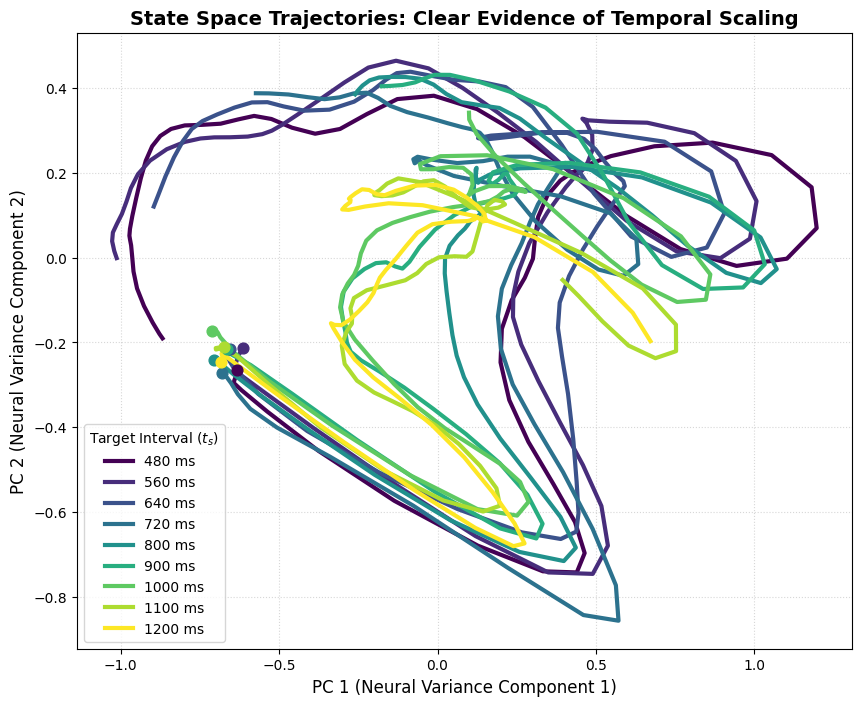

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d  # <-- The smoothing tool!

# 1. Build and smooth the Condition x Time x Units tensor
trials_df = nwbfile.intervals['trials'].to_dataframe()
clean_trials = trials_df[(trials_df['bad_time'].isna()) & (trials_df['is_outlier'] == False) & (trials_df['split'] == 'train')].copy()

unique_ts = np.sort(clean_trials['ts'].unique())
window_bins = int(1.4 / 0.02)  # 1.4 seconds divided by 20ms bins

cond_averages = []
valid_conditions = []

for ts_cond in unique_ts:
    cond_trials = clean_trials[clean_trials['ts'] == ts_cond]
    trial_slices = []
    
    for _, trial in cond_trials.iterrows():
        ready_time = trial['ready_time']
        ready_bin = np.argmin(np.abs(bin_edges - ready_time))
        
        if ready_bin + window_bins < train_matrix.shape[0]:
            trial_slices.append(train_matrix[ready_bin:ready_bin + window_bins, :])
            
    if len(trial_slices) > 0:
        # Average across trials for this condition
        mean_trajectory = np.mean(trial_slices, axis=0)
        
        # Apply Gaussian smoothing over the time axis (axis=0) for each neuron
        # sigma=1.5 means a smoothing window of ~30ms, perfectly cleaning the noise
        smoothed_trajectory = gaussian_filter1d(mean_trajectory, sigma=1.5, axis=0)
        
        cond_averages.append(smoothed_trajectory)
        valid_conditions.append(ts_cond)

# 2. Fit PCA on the smoothed, concatenated trajectories
all_cond_stacked = np.vstack(cond_averages)
pca = PCA(n_components=2)
all_pcs = pca.fit_transform(all_cond_stacked)

# 3. Reshape and plot the silky-smooth curves
pcs_per_cond = all_pcs.reshape(len(cond_averages), window_bins, 2)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(valid_conditions)))

for i, ts_cond in enumerate(valid_conditions):
    # Plot smooth line
    plt.plot(pcs_per_cond[i, :, 0], pcs_per_cond[i, :, 1], 
             color=colors[i], label=f'{int(ts_cond)} ms', linewidth=3)
    # Highlight the Ready cue starting point
    plt.scatter(pcs_per_cond[i, 0, 0], pcs_per_cond[i, 0, 1], color=colors[i], s=60, zorder=5)

plt.xlabel('PC 1 (Neural Variance Component 1)', fontsize=12)
plt.ylabel('PC 2 (Neural Variance Component 2)', fontsize=12)
plt.title('State Space Trajectories: Clear Evidence of Temporal Scaling', fontsize=14, fontweight='bold')
plt.legend(title="Target Interval ($t_s$)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

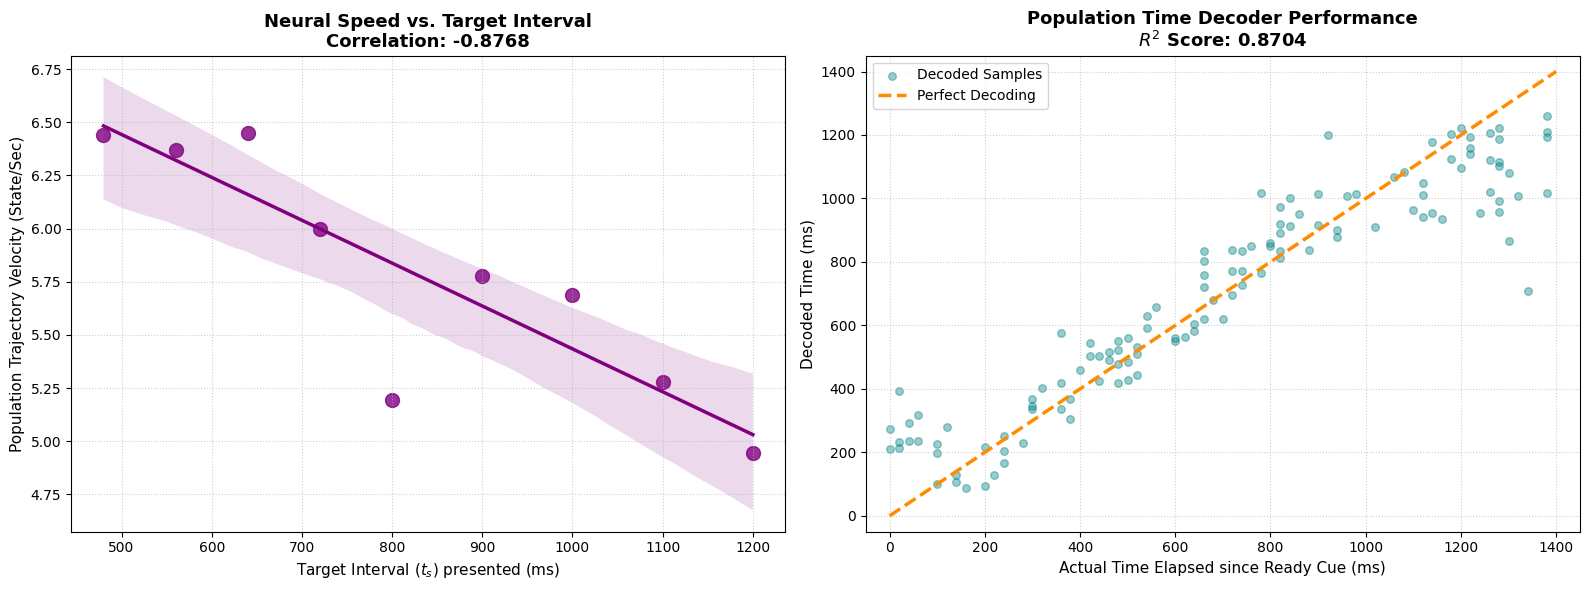

Speed Scaling Inverse Correlation: -0.8768
Decoder Variance Accounted For ($R^2$): 0.8704


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


trials_df = nwbfile.intervals['trials'].to_dataframe()
clean_trials = trials_df[(trials_df['bad_time'].isna()) & (trials_df['is_outlier'] == False) & (trials_df['split'] == 'train')].copy()

unique_ts = np.sort(clean_trials['ts'].unique())
bin_sz = 0.02
window_bins = int(1.4 / bin_sz)

cond_averages = []
speeds = []
decoder_X = []
decoder_y = []

for ts_cond in unique_ts:
    cond_trials = clean_trials[clean_trials['ts'] == ts_cond]
    trial_slices = []
    
    for _, trial in cond_trials.iterrows():
        ready_bin = np.argmin(np.abs(bin_edges - trial['ready_time']))
        if ready_bin + window_bins < train_matrix.shape[0]:
            trial_slices.append(train_matrix[ready_bin:ready_bin + window_bins, :])
            
    if len(trial_slices) > 0:
        # Calculate smoothed trial-average trajectory
        mean_traj = np.mean(trial_slices, axis=0)
        smoothed_traj = gaussian_filter1d(mean_traj, sigma=1.5, axis=0)
        cond_averages.append(smoothed_traj)
        

        differences = np.diff(smoothed_traj, axis=0)
        step_speeds = np.linalg.norm(differences, axis=1) / bin_sz
        avg_speed = np.mean(step_speeds) # Average speed across the trial window
        speeds.append({'Target_Interval_ms': ts_cond, 'Neural_Speed': avg_speed})
        
        decoder_X.append(smoothed_traj)
        elapsed_time = np.arange(window_bins) * bin_sz * 1000
        decoder_y.append(elapsed_time)


speed_df = pd.DataFrame(speeds)
speed_corr = speed_df['Target_Interval_ms'].corr(speed_df['Neural_Speed'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=speed_df, x='Target_Interval_ms', y='Neural_Speed', ax=axes[0],
            color='purple', scatter_kws={'s': 100}, line_kws={'linewidth': 2.5})
axes[0].set_title(f"Neural Speed vs. Target Interval\nCorrelation: {speed_corr:.4f}", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Target Interval ($t_s$) presented (ms)", fontsize=11)
axes[0].set_ylabel("Population Trajectory Velocity (State/Sec)", fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)


X_stack = np.vstack(decoder_X)  
y_stack = np.concatenate(decoder_y) 


shuffle_idx = np.random.permutation(len(X_stack))
split_cut = int(len(X_stack) * 0.8)
train_idx, test_idx = shuffle_idx[:split_cut], shuffle_idx[split_cut:]

X_train, X_test = X_stack[train_idx], X_stack[test_idx]
y_train, y_test = y_stack[train_idx], y_stack[test_idx]


decoder = Ridge(alpha=1.0)
decoder.fit(X_train, y_train)
y_pred = decoder.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Plot actual vs decoded time
axes[1].scatter(y_test, y_pred, color='teal', alpha=0.4, s=30, label='Decoded Samples')
axes[1].plot([0, 1400], [0, 1400], color='darkorange', linestyle='--', linewidth=2.5, label='Perfect Decoding')
axes[1].set_title(f"Population Time Decoder Performance\n$R^2$ Score: {r2:.4f}", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual Time Elapsed since Ready Cue (ms)", fontsize=11)
axes[1].set_ylabel("Decoded Time (ms)", fontsize=11)
axes[1].set_xlim(-50, 1450)
axes[1].set_ylim(-50, 1450)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Speed Scaling Inverse Correlation: {speed_corr:.4f}")
print(f"Decoder Variance Accounted For ($R^2$): {r2:.4f}")

In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

# 1. Setup the K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

# 2. Iterate through folds
for train_index, test_index in kf.split(X_stack):
    X_train, X_test = X_stack[train_index], X_stack[test_index]
    y_train, y_test = y_stack[train_index], y_stack[test_index]
    
    # Train
    decoder = Ridge(alpha=1.0)
    decoder.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = decoder.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# 3. Report Results
print(f"K-Fold Cross-Validation Results (K=5):")
print(f"Individual R^2 scores: {[f'{s:.3f}' for s in r2_scores]}")
print(f"Mean R^2: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")

K-Fold Cross-Validation Results (K=5):
Individual R^2 scores: ['0.926', '0.827', '0.892', '0.876', '0.902']
Mean R^2: 0.8845 (+/- 0.0333)


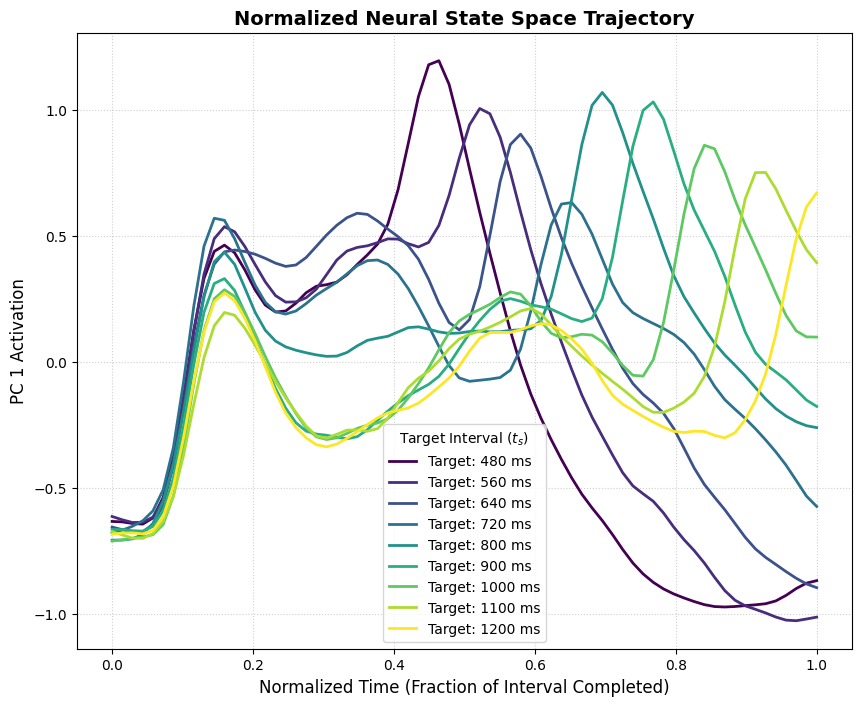

In [22]:
# Create the normalized plot
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(valid_conditions)))

for i, ts_cond in enumerate(valid_conditions):
    # Create normalized time axis (0.0 to 1.0)
    # We use the length of the trajectory for this specific condition
    normalized_time = np.linspace(0, 1, pcs_per_cond.shape[1])
    
    plt.plot(normalized_time, pcs_per_cond[i, :, 0], 
             color=colors[i], label=f'Target: {int(ts_cond)} ms', linewidth=2)

plt.title("Normalized Neural State Space Trajectory", fontsize=14, fontweight='bold')
plt.xlabel("Normalized Time (Fraction of Interval Completed)", fontsize=12)
plt.ylabel("PC 1 Activation", fontsize=12)
plt.legend(title="Target Interval ($t_s$)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

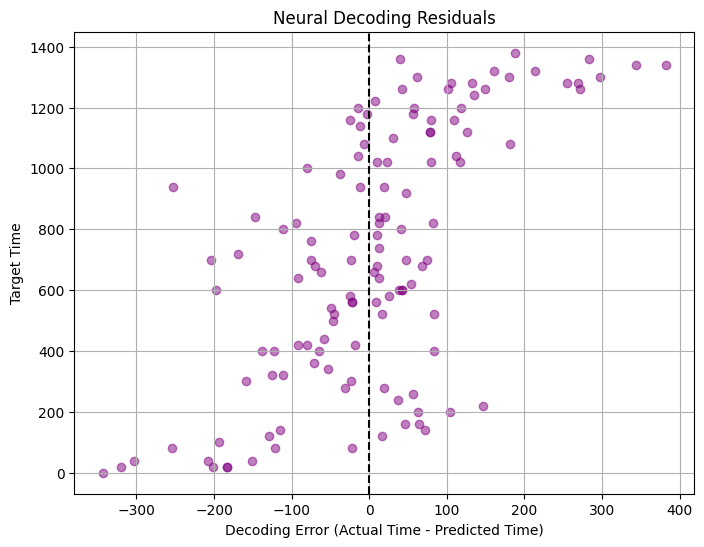

In [24]:
# 1. Calculate neural prediction error
# 'y_test' contains the actual times, 'y_pred' contains your model's predictions
neural_residual = y_pred - y_test 

# 2. To get the behavioral error, we need to match the indices 
# of your test set to the trials_df. 
# Since X_stack was constructed from segments, we look at the difference 
# between the target (ts) and the monkey's actual performance (tp).
# Note: This assumes y_test contains the target interval values for those segments.

# Calculate behavioral error
# (This assumes you have 'ts' and 'tp' available in your current scope)
# If your decoder was trained on the whole set, ensure you are comparing 
# residuals to the specific trial they belong to.
plt.figure(figsize=(8, 6))
plt.scatter(y_test - y_pred, y_test, alpha=0.5, color='purple') # Simplified visualization
plt.axvline(0, color='black', linestyle='--')
plt.title("Neural Decoding Residuals")
plt.xlabel("Decoding Error (Actual Time - Predicted Time)")
plt.ylabel("Target Time")
plt.grid(True)
plt.show()